In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [332]:
df=pd.read_csv("/content/framingham.csv")

In [333]:
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [335]:
df.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [336]:
df.drop(columns="education",inplace=True)

In [337]:
df["cigsPerDay"].fillna(value=0,inplace=True)

<ipython-input-337-4e449e2acef4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cigsPerDay"].fillna(value=0,inplace=True)


# Data distribution

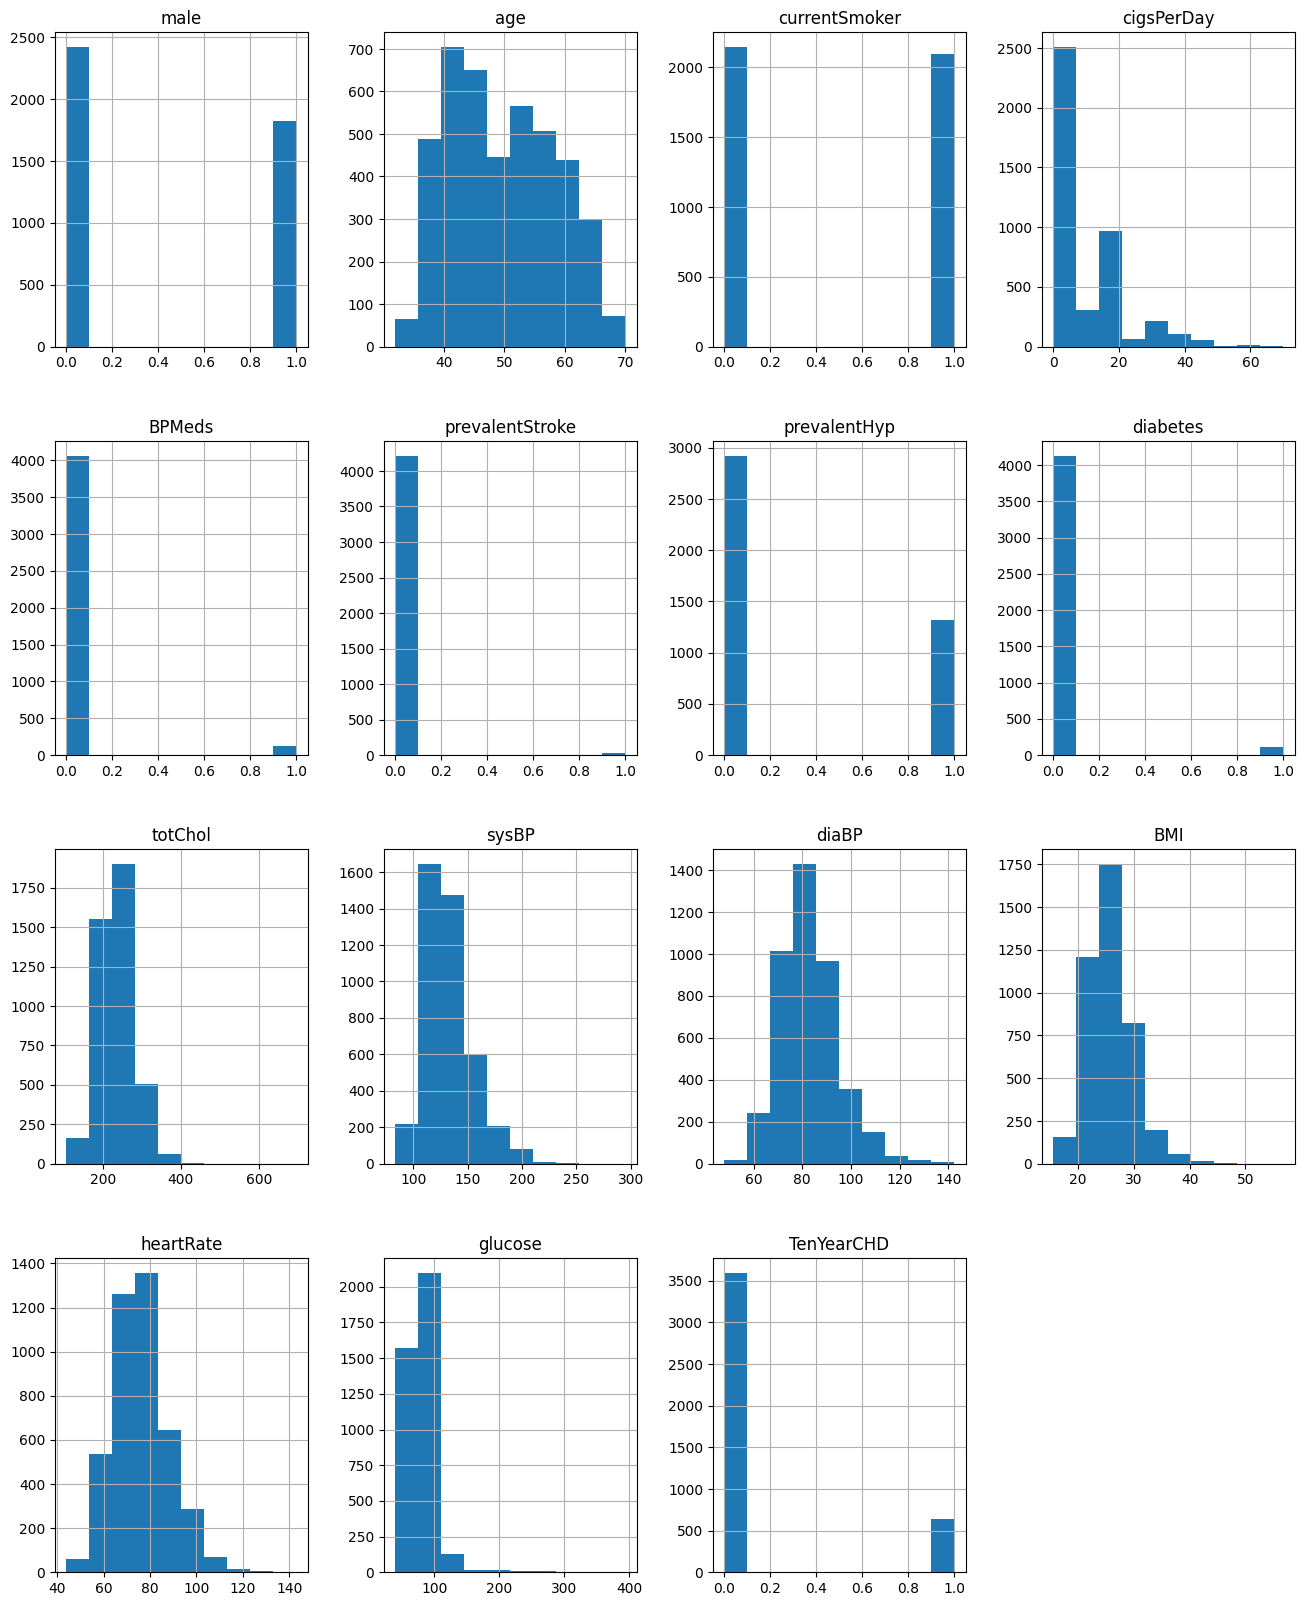

In [338]:
df.hist(figsize=(16,20));

In [339]:
X=df.drop(columns=["TenYearCHD"])
y=df["TenYearCHD"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [340]:
y.value_counts(normalize=True)

,proportion
TenYearCHD,
0,0.848042
1,0.151958


In [341]:
y_test.value_counts(normalize=True)

,proportion
TenYearCHD,
0,0.847877
1,0.152123


In [342]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,classification_report

In [343]:
LR_model=make_pipeline(
    SimpleImputer(strategy="mean"),
    MinMaxScaler(),
    LogisticRegression()
)
LR_model.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('minmaxscaler', MinMaxScaler()),
                ('logisticregression', LogisticRegression())])

In [344]:
y_training_pred=LR_model.predict(X_train)
y_testing_pred=LR_model.predict(X_test)
print("Training acuuracy",accuracy_score(y_train,y_training_pred))
print("Testing acuuracy",accuracy_score(y_test,y_testing_pred))

Training acuuracy 0.856637168141593
Testing acuuracy 0.8490566037735849


In [345]:
print(classification_report(y_test,y_testing_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.54      0.05      0.10       129

    accuracy                           0.85       848
   macro avg       0.70      0.52      0.51       848
weighted avg       0.81      0.85      0.79       848



# Confusion matrix

In [346]:
cm=confusion_matrix(y_test,y_testing_pred)

In [347]:
cm

array([[713,   6],
       [122,   7]])

In [348]:
#        Predicted
#           0     1
# Actual  --------------
#    0  |  TN   |  FP  |
#       |--------|------|
#    1  |  FN   |  TP  |
#       |--------|------|

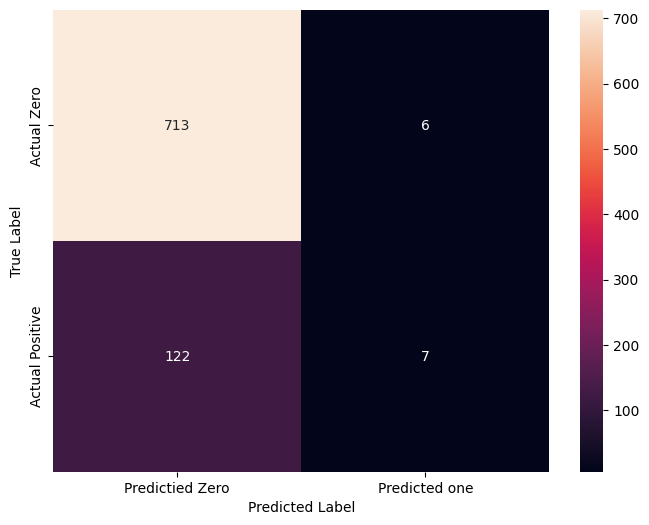

In [349]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,xticklabels=["Predictied Zero","Predicted one"],yticklabels=["Actual Zero","Actual Positive"],fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [350]:
# data = {
#     "Feature1": np.random.rand(100),
#     "Feature2": np.random.rand(100),
#     "Class": np.random.choice([0,1, 2], size=100, p=[0.2, 0.5, 0.3]),
# }

# df = pd.DataFrame(data)

In [351]:
# df["Class"].value_counts(normalize=True)

In [352]:
# X=df.drop(columns=["Class"])
# y=df["Class"]
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [353]:
# y.value_counts(normalize=True)

In [354]:
# y_train.value_counts(normalize=True)

In [355]:
# y_test.value_counts(normalize=True)

In [356]:
# LR=LogisticRegression(multi_class="ovr")

In [357]:
# LR.fit(X_train,y_train)

In [358]:
X_Series=pd.Series(LR_model.predict(X_test))

In [359]:
X_Series[X_Series==1]

,0
79,1
82,1
122,1
170,1
225,1
343,1
469,1
605,1
621,1
628,1


In [360]:
y_prob=LR_model.predict_proba(X_test)[:,1]

In [361]:
y_prob

array([0.20096932, 0.21761142, 0.18960006, 0.48968805, 0.21872341,
       0.18890365, 0.24862039, 0.08408717, 0.13712204, 0.18256355,
       0.05881135, 0.13617699, 0.10136516, 0.33021672, 0.10119851,
       0.16436266, 0.06254515, 0.07035512, 0.12001594, 0.30266771,
       0.07595712, 0.09596551, 0.07434109, 0.24167938, 0.1259522 ,
       0.21303561, 0.1044074 , 0.14987739, 0.14777807, 0.04633612,
       0.07048179, 0.08568164, 0.28022838, 0.46301828, 0.08281693,
       0.08103543, 0.07927642, 0.12235903, 0.0514458 , 0.11116596,
       0.27198393, 0.14359968, 0.03245565, 0.31151003, 0.30205696,
       0.31812349, 0.14851553, 0.07723857, 0.23821018, 0.18303212,
       0.09792731, 0.24637447, 0.07663214, 0.18090418, 0.05952135,
       0.28654727, 0.35739187, 0.06613788, 0.0558531 , 0.28304264,
       0.03998949, 0.08165642, 0.16563667, 0.15356251, 0.16425583,
       0.46649659, 0.12361441, 0.30655689, 0.09416007, 0.160296  ,
       0.07170001, 0.21080875, 0.29429221, 0.2206924 , 0.23758

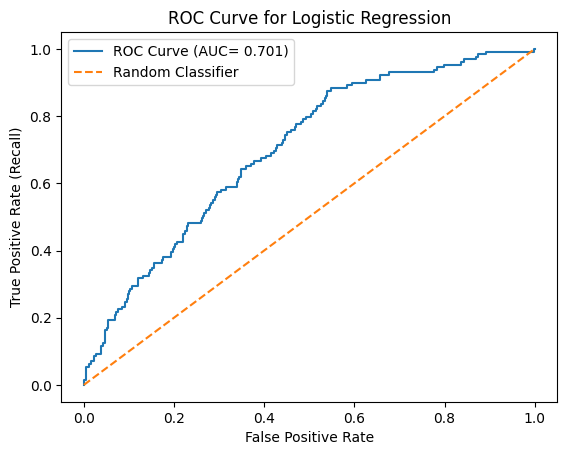

In [362]:
from sklearn.metrics import roc_curve,roc_auc_score
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test,y_prob)
plt.plot(fpr,tpr,label=f"ROC Curve (AUC= {round(auc,3)})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()

In [363]:
auc

0.7011784239523023

In [364]:
fpr

array([0.        , 0.        , 0.        , 0.00417246, 0.00417246,
       0.00556328, 0.00556328, 0.01112656, 0.01112656, 0.01529903,
       0.01529903, 0.02225313, 0.02225313, 0.02642559, 0.02642559,
       0.03894298, 0.03894298, 0.04172462, 0.04172462, 0.0472879 ,
       0.0472879 , 0.05146036, 0.05146036, 0.05285118, 0.05285118,
       0.054242  , 0.054242  , 0.06815021, 0.06815021, 0.07232267,
       0.07232267, 0.07510431, 0.07510431, 0.08484006, 0.08484006,
       0.09040334, 0.09040334, 0.09596662, 0.09596662, 0.09874826,
       0.09874826, 0.10013908, 0.10013908, 0.10292072, 0.10292072,
       0.10709318, 0.10709318, 0.12100139, 0.12100139, 0.13073713,
       0.13073713, 0.14464534, 0.14464534, 0.14742698, 0.14742698,
       0.15020862, 0.15020862, 0.15577191, 0.15577191, 0.17246175,
       0.17246175, 0.17663421, 0.17663421, 0.19332406, 0.19332406,
       0.19749652, 0.19749652, 0.20027816, 0.20027816, 0.20166898,
       0.20166898, 0.20584145, 0.20584145, 0.21974965, 0.21974

In [365]:
tpr

array([0.        , 0.00775194, 0.01550388, 0.01550388, 0.03875969,
       0.03875969, 0.05426357, 0.05426357, 0.0620155 , 0.0620155 ,
       0.06976744, 0.06976744, 0.08527132, 0.08527132, 0.09302326,
       0.09302326, 0.11627907, 0.11627907, 0.12403101, 0.12403101,
       0.1627907 , 0.1627907 , 0.17054264, 0.17054264, 0.17829457,
       0.17829457, 0.19379845, 0.19379845, 0.20930233, 0.20930233,
       0.21705426, 0.21705426, 0.2248062 , 0.2248062 , 0.23255814,
       0.23255814, 0.24806202, 0.24806202, 0.25581395, 0.25581395,
       0.27131783, 0.27131783, 0.27906977, 0.27906977, 0.28682171,
       0.28682171, 0.29457364, 0.29457364, 0.31782946, 0.31782946,
       0.3255814 , 0.3255814 , 0.33333333, 0.33333333, 0.34108527,
       0.34108527, 0.34883721, 0.34883721, 0.36434109, 0.36434109,
       0.37209302, 0.37209302, 0.37984496, 0.37984496, 0.39534884,
       0.39534884, 0.40310078, 0.40310078, 0.41085271, 0.41085271,
       0.41860465, 0.41860465, 0.42635659, 0.42635659, 0.44961

In [366]:
thresholds

array([       inf, 0.61513893, 0.58599594, 0.5633099 , 0.5492661 ,
       0.54239318, 0.51332196, 0.49354014, 0.49140629, 0.47308621,
       0.46854626, 0.45505505, 0.44399608, 0.42758889, 0.41044148,
       0.37419308, 0.36540283, 0.35954591, 0.3585291 , 0.35149082,
       0.34680286, 0.33804217, 0.33596057, 0.33021672, 0.32793212,
       0.32706498, 0.3245895 , 0.31027992, 0.30864108, 0.30386158,
       0.30348236, 0.30295171, 0.30289981, 0.29612268, 0.29429221,
       0.28833485, 0.28734726, 0.28571419, 0.28563599, 0.28304264,
       0.28222964, 0.28128265, 0.28036487, 0.2798343 , 0.27677887,
       0.27398209, 0.27198393, 0.25255599, 0.25104882, 0.24830137,
       0.24759213, 0.24355305, 0.2429817 , 0.24167938, 0.24077965,
       0.23889931, 0.23821018, 0.23494416, 0.23313877, 0.22536257,
       0.22478553, 0.22279126, 0.2206924 , 0.21303561, 0.21299972,
       0.21009038, 0.20966686, 0.20785135, 0.20661478, 0.20506514,
       0.20170792, 0.19997584, 0.19981765, 0.19441045, 0.19344

In [367]:
list(zip(fpr,tpr,thresholds))

[(0.0, 0.0, inf),
 (0.0, 0.007751937984496124, 0.6151389305124744),
 (0.0, 0.015503875968992248, 0.5859959371629191),
 (0.004172461752433936, 0.015503875968992248, 0.5633099020417216),
 (0.004172461752433936, 0.03875968992248062, 0.5492661022692381),
 (0.005563282336578581, 0.03875968992248062, 0.542393182828538),
 (0.005563282336578581, 0.05426356589147287, 0.513321956217772),
 (0.011126564673157162, 0.05426356589147287, 0.4935401350213228),
 (0.011126564673157162, 0.06201550387596899, 0.49140628847851064),
 (0.015299026425591099, 0.06201550387596899, 0.47308621213198576),
 (0.015299026425591099, 0.06976744186046512, 0.46854626366574126),
 (0.022253129346314324, 0.06976744186046512, 0.4550550475129924),
 (0.022253129346314324, 0.08527131782945736, 0.4439960843702946),
 (0.02642559109874826, 0.08527131782945736, 0.4275888898930238),
 (0.02642559109874826, 0.09302325581395349, 0.41044147677967563),
 (0.03894297635605007, 0.09302325581395349, 0.37419307686976877),
 (0.03894297635605007, 

In [368]:
for f,t,thr in zip(fpr,tpr,thresholds):
  print(f"Threshold: {thr:.2f}, FPR: {f:.2f}, TPR: {t:.2f}")

Threshold: inf, FPR: 0.00, TPR: 0.00
Threshold: 0.62, FPR: 0.00, TPR: 0.01
Threshold: 0.59, FPR: 0.00, TPR: 0.02
Threshold: 0.56, FPR: 0.00, TPR: 0.02
Threshold: 0.55, FPR: 0.00, TPR: 0.04
Threshold: 0.54, FPR: 0.01, TPR: 0.04
Threshold: 0.51, FPR: 0.01, TPR: 0.05
Threshold: 0.49, FPR: 0.01, TPR: 0.05
Threshold: 0.49, FPR: 0.01, TPR: 0.06
Threshold: 0.47, FPR: 0.02, TPR: 0.06
Threshold: 0.47, FPR: 0.02, TPR: 0.07
Threshold: 0.46, FPR: 0.02, TPR: 0.07
Threshold: 0.44, FPR: 0.02, TPR: 0.09
Threshold: 0.43, FPR: 0.03, TPR: 0.09
Threshold: 0.41, FPR: 0.03, TPR: 0.09
Threshold: 0.37, FPR: 0.04, TPR: 0.09
Threshold: 0.37, FPR: 0.04, TPR: 0.12
Threshold: 0.36, FPR: 0.04, TPR: 0.12
Threshold: 0.36, FPR: 0.04, TPR: 0.12
Threshold: 0.35, FPR: 0.05, TPR: 0.12
Threshold: 0.35, FPR: 0.05, TPR: 0.16
Threshold: 0.34, FPR: 0.05, TPR: 0.16
Threshold: 0.34, FPR: 0.05, TPR: 0.17
Threshold: 0.33, FPR: 0.05, TPR: 0.17
Threshold: 0.33, FPR: 0.05, TPR: 0.18
Threshold: 0.33, FPR: 0.05, TPR: 0.18
Threshold: 0.

In [369]:
11//2

5

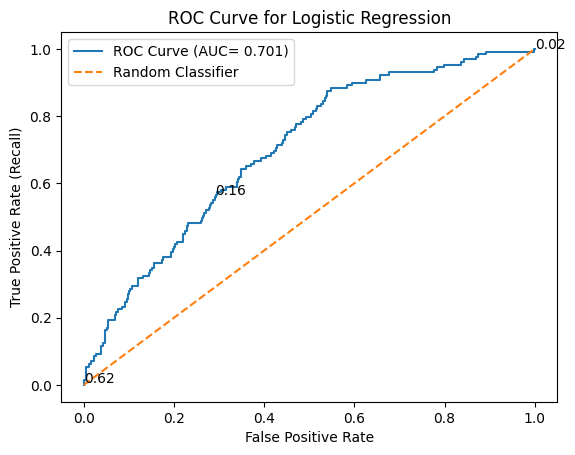

In [370]:
from sklearn.metrics import roc_curve,roc_auc_score
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test,y_prob)
plt.plot(fpr,tpr,label=f"ROC Curve (AUC= {round(auc,3)})")
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")

threshold_idx=[1,len(thresholds)//2,-1] # strart ,middle,end
for idx in  threshold_idx:
  plt.annotate(f"{round(thresholds[idx],2)}",(fpr[idx],tpr[idx]))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()

In [371]:
y_prob=LR_model.predict_proba(X_test)[:,1]
threshold=0.2
y_pred_custom=(y_prob>=threshold).astype(int)

In [372]:
print(classification_report(y_test , y_pred_custom))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       719
           1       0.27      0.42      0.33       129

    accuracy                           0.74       848
   macro avg       0.58      0.61      0.58       848
weighted avg       0.79      0.74      0.76       848



In [373]:
import pickle
pickle.dump(LR_model,open("model_LogisticRegression.pkl","wb"))